In [3]:
import json
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from plot_config import apply_plot_config


In [4]:
apply_plot_config()

# Fixed Variables

In [5]:
statements = ['same', 'different']
models = ['mistral', 'llama3']
initials = ['balanced', 'polarized', 'unbalanced']

niter = 30
nruns = 12
N = 140

opinion_space = [0, 1, 2, 3, 4, 5, 6]

c = (1 / 2.54) / 10 
width = 170*c
height = 80*c

## Transition matrices with percentages wrt total transitions by row, averaged over nruns (percentages):

/tmp/ipykernel_876608/2844131880.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave space for colorbar


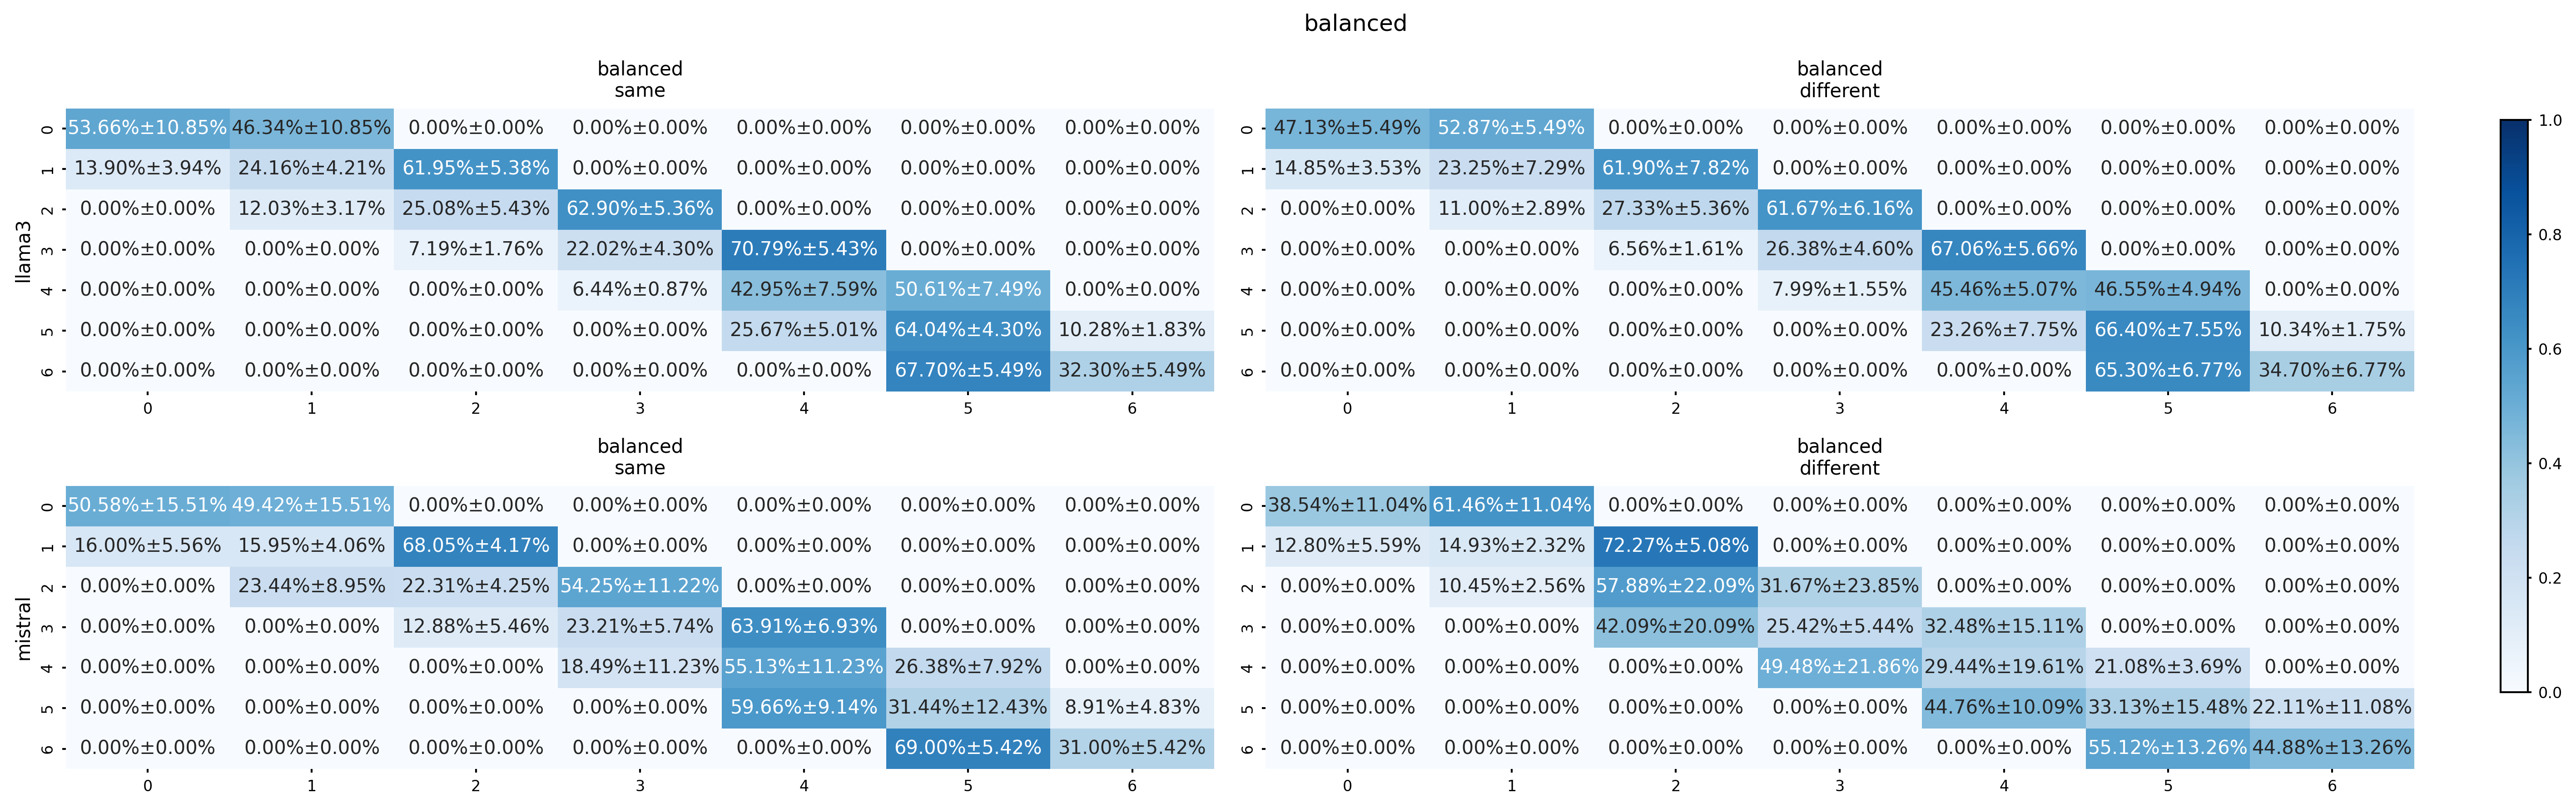

/tmp/ipykernel_876608/2844131880.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave space for colorbar


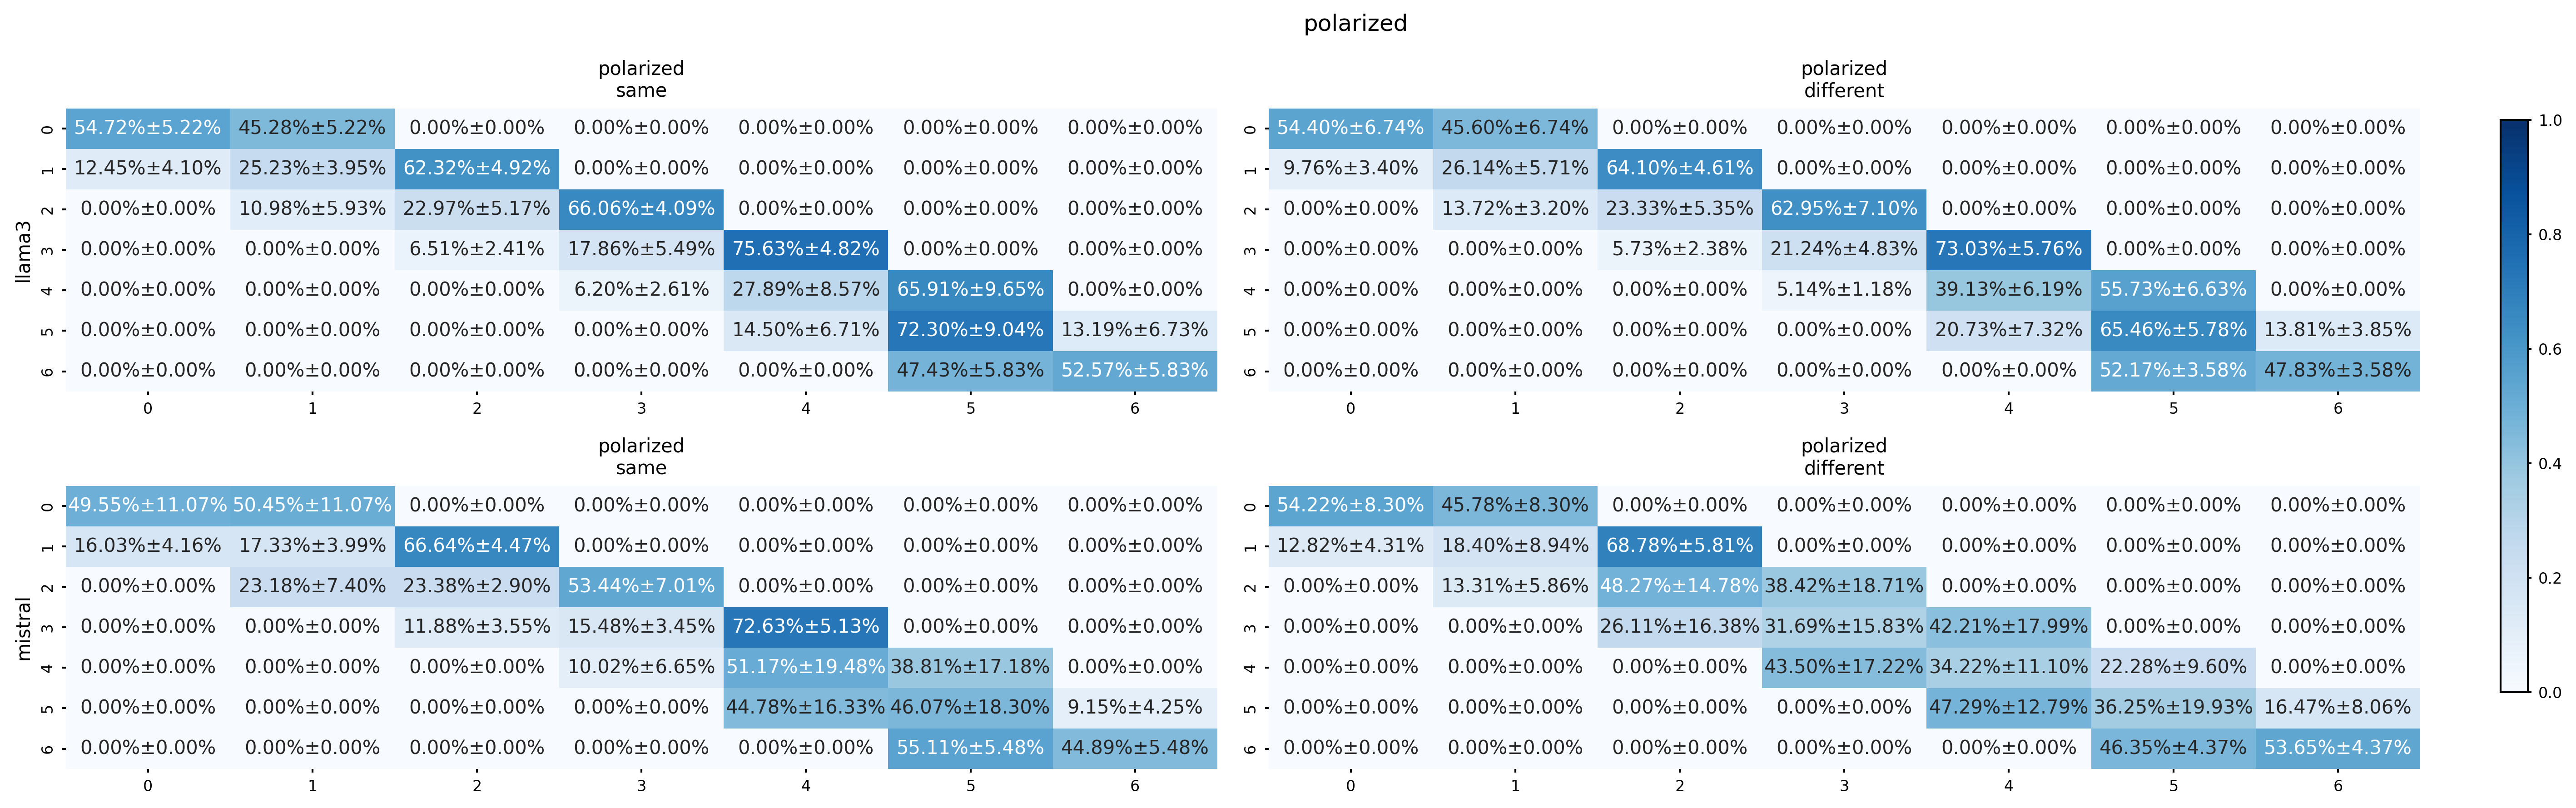

/tmp/ipykernel_876608/2844131880.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave space for colorbar


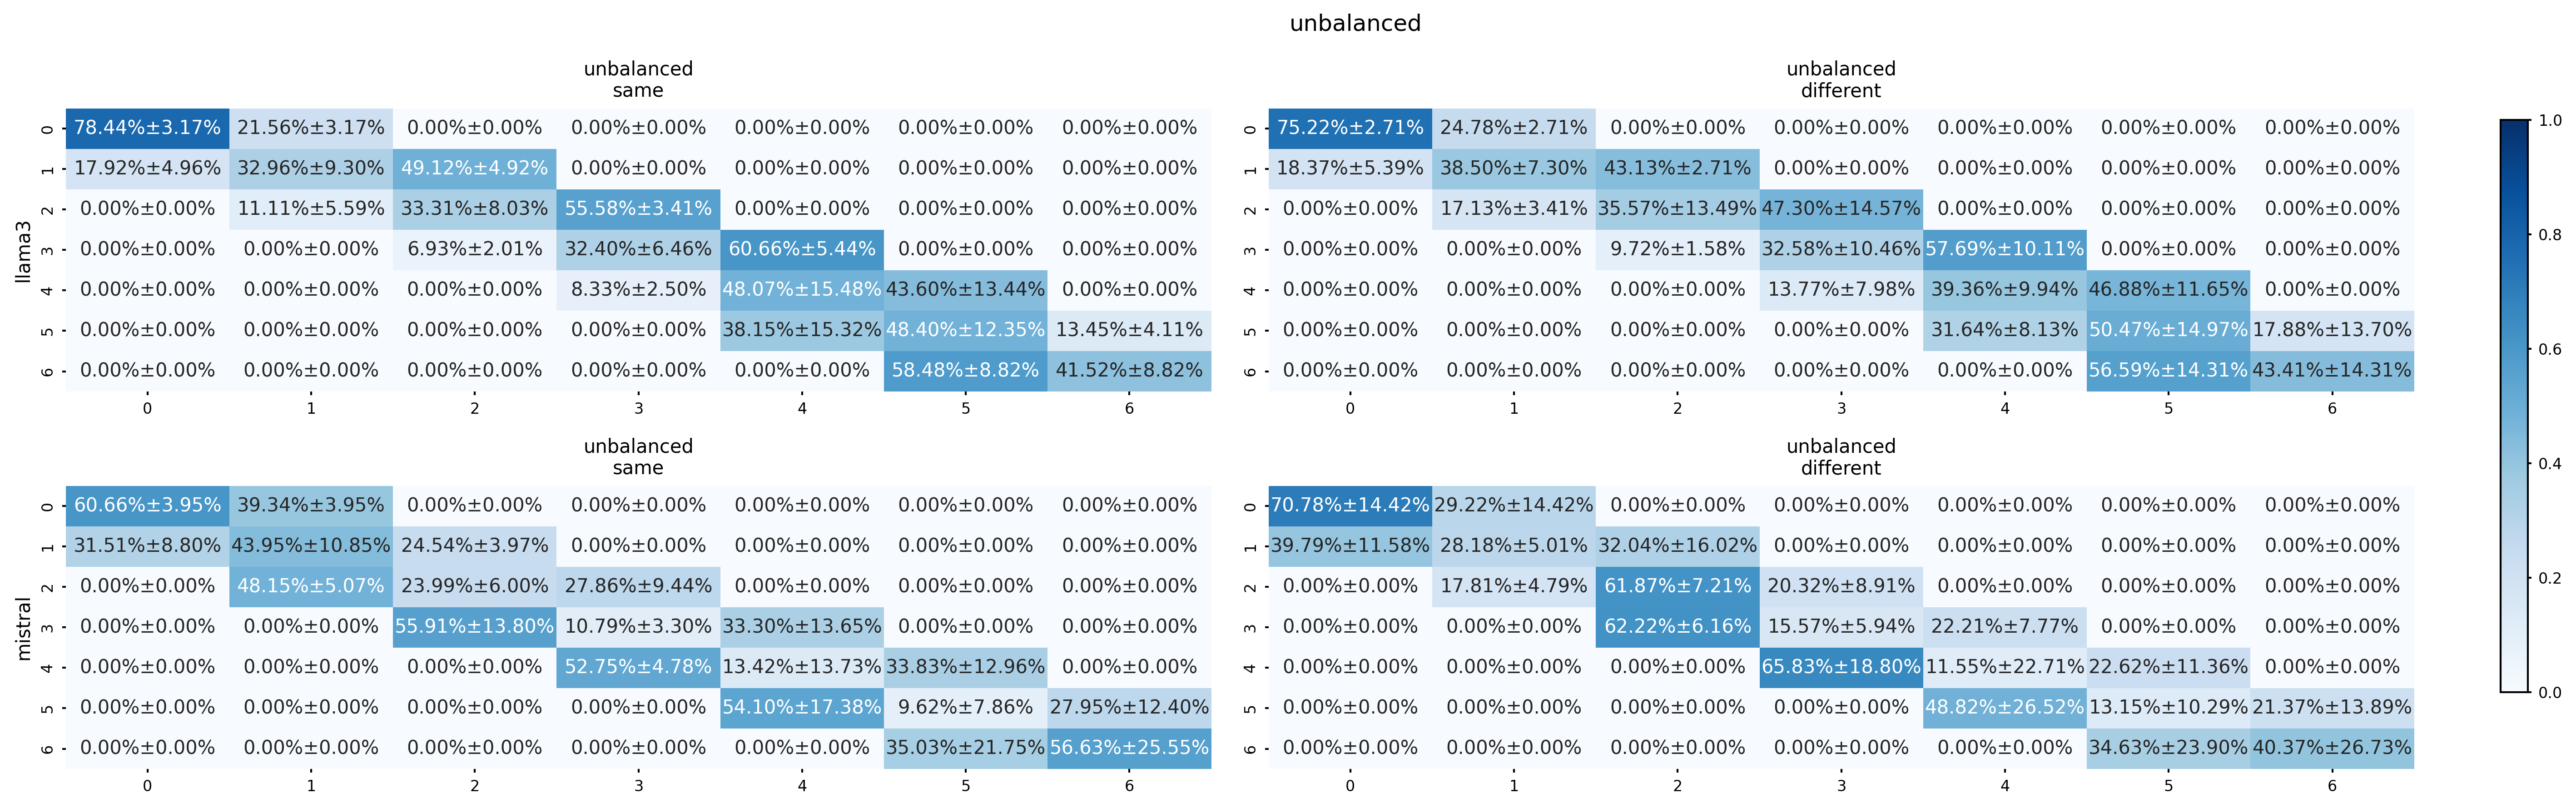

In [6]:
epsilon = 1e-12  # Small value to avoid division by zero

for _, initial in enumerate(initials):
    fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(20, 6))
    heatmaps = []

    for col, statement in enumerate(statements):
        for row, model in enumerate(models):
            matrices = []
            for run in range(nruns):
                with open(f"results/{initial}/transition_matrix_{statement}_{model}_{run}.npy", 'rb') as f:
                    transition_matrix = np.load(f)

                    s = transition_matrix.sum(axis=1, keepdims=True)

                    # Create a mask for rows where the sum is zero
                    zero_rows = (s == 0)

                    # Avoid division by zero by using np.where
                    safe_s = np.where(s == 0, 1, s)  # Replace 0 with 1 to prevent division error
                    transition_matrix = transition_matrix / safe_s

                    # Set entire rows that had zero sum to 0 after division
                    transition_matrix[zero_rows.flatten()] = 0.0
                    
                    #transition_matrix = np.nan_to_num(transition_matrix)
                    matrices.append(transition_matrix)

            matrices = np.stack(matrices)
            avg_transition_matrix = np.mean(matrices, axis=0)
            std_transition_matrix = np.std(matrices, axis=0)

            labels = np.array([
                [f"{mean:.2%}±{std:.2%}" for mean, std in zip(row_mean, row_std)]
                for row_mean, row_std in zip(avg_transition_matrix, std_transition_matrix)
            ])

            hm = sns.heatmap(
                avg_transition_matrix,
                annot=labels,
                fmt='',
                cmap='Blues',
                cbar=False,
                ax=ax[row, col],
                vmin=0, vmax=1
            )
            heatmaps.append(hm)
            ax[row, col].set_title(f"{initial}\n{statement}", fontsize=10)

    # Shared colorbar on the right
    cbar_ax = fig.add_axes([0.92, 0.15, 0.01, 0.7])  # [left, bottom, width, height]
    fig.colorbar(heatmaps[0].collections[0], cax=cbar_ax)

    ax[0, 0].set_ylabel('llama3')
    ax[1, 0].set_ylabel('mistral')

    plt.suptitle(initial)
    plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave space for colorbar
    plt.show()
    plt.close()


## Percentages wrt total transitions by row, averaged over nruns:

NameError: name 'rules' is not defined

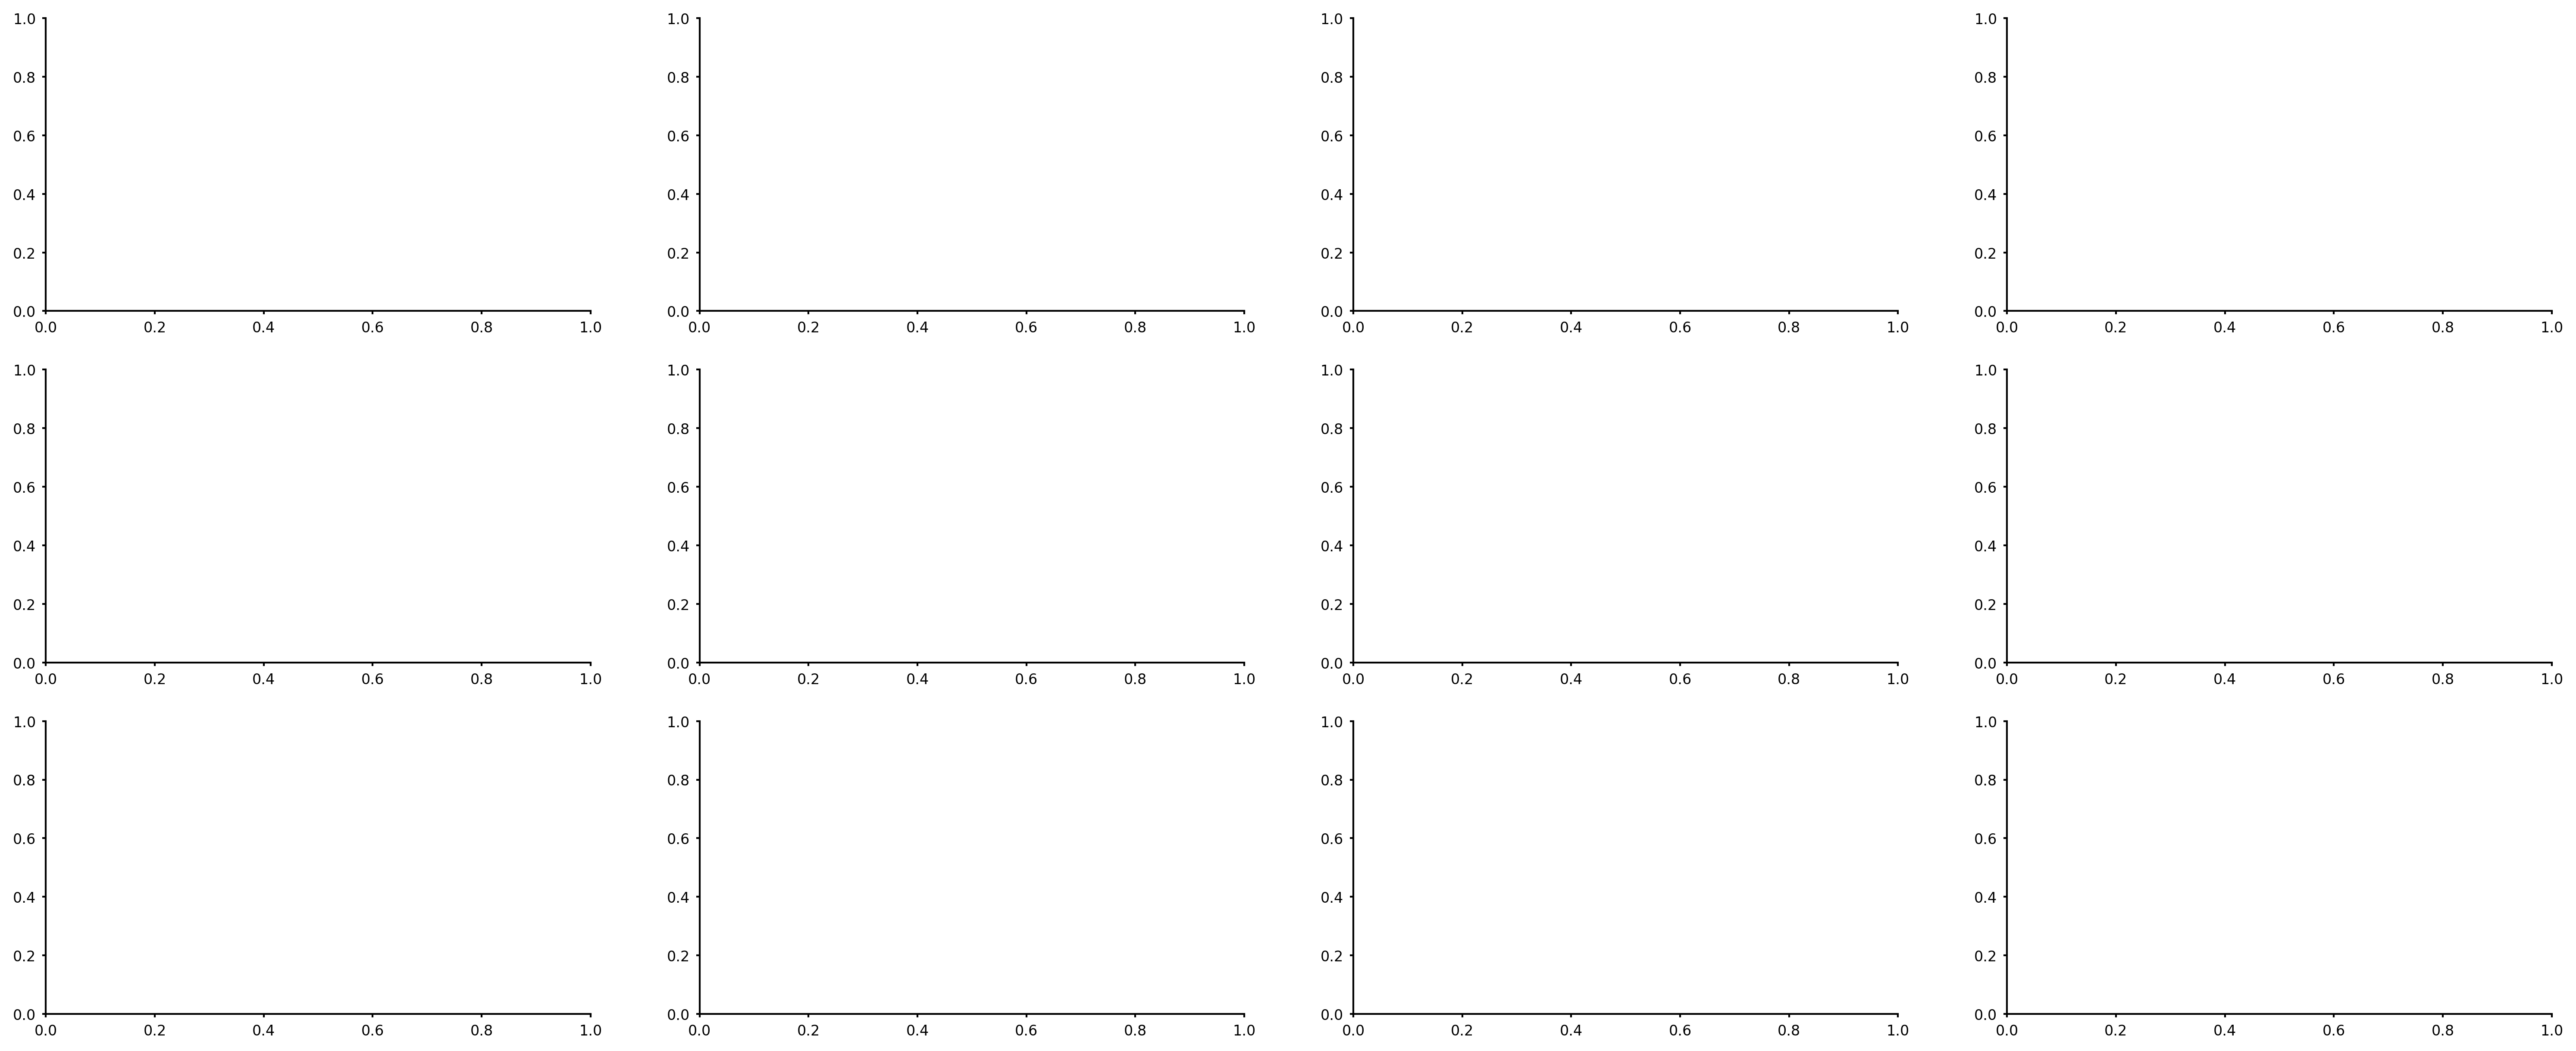

In [7]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(25, 10))

for col, rule in enumerate(rules):   #remember that rules is only random for now
    
    for row, initial in enumerate(initials):
        
        ax = axes[row, col]
        
        matrices = []
        for run in range(nruns):
            with open(f"results/{initial}/transition_matrix_{rule}_{run}.npy", 'rb') as f:
                transition_matrix = np.load(f)
                transition_matrix /= transition_matrix.sum(axis=1, keepdims=True)
                transition_matrix = np.nan_to_num(transition_matrix)
                matrices.append(transition_matrix)
        
        matrices = np.stack(matrices)  
        avg_transition_matrix = np.mean(matrices, axis=0)
        std_transition_matrix = np.std(matrices, axis=0)
                
        labels = np.array([[f"{mean:.2f}±{std:.2f}" if mean > 0 else "" for mean, std in zip(row_mean, row_std)]
                for row_mean, row_std in zip(avg_transition_matrix, std_transition_matrix)])
            
        hm = sns.heatmap(avg_transition_matrix, 
                         annot=labels, 
                         fmt='', 
                         cmap='Blues', 
                         cbar=False, 
                         ax=ax, 
                         annot_kws={'size': 10}, 
                         vmin=0, 
                         vmax=1)
            
        ax.set_title(f"{initial}\n{rule}", fontsize=15)

plt.tight_layout()  # Leave space for colorbar
plt.show()
plt.close()

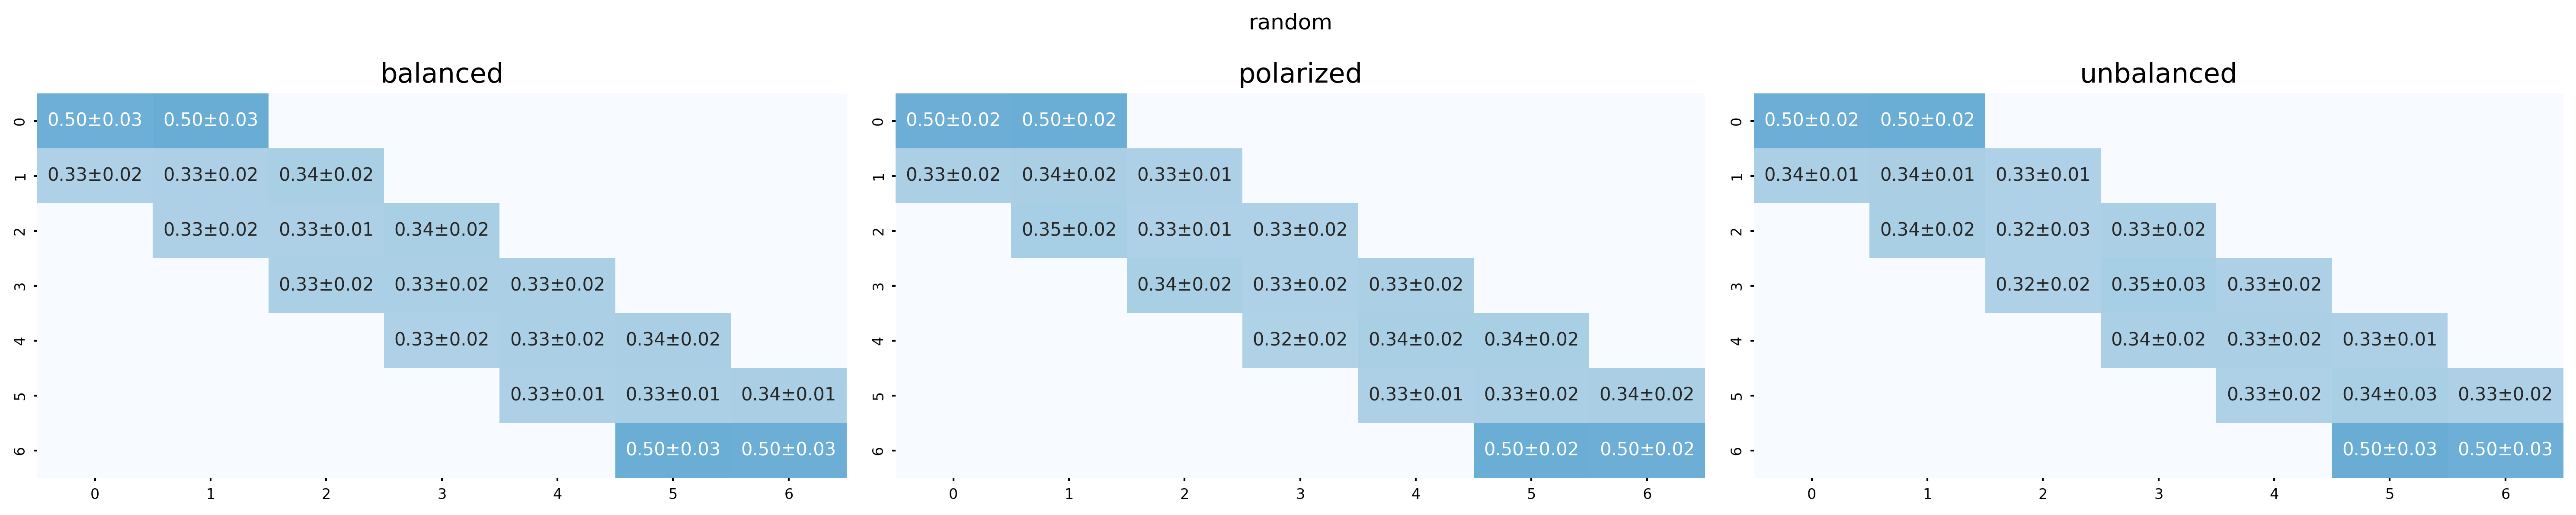

/tmp/ipykernel_842942/379097225.py:13: RuntimeWarning: invalid value encountered in divide
  transition_matrix /= transition_matrix.sum(axis=1, keepdims=True)


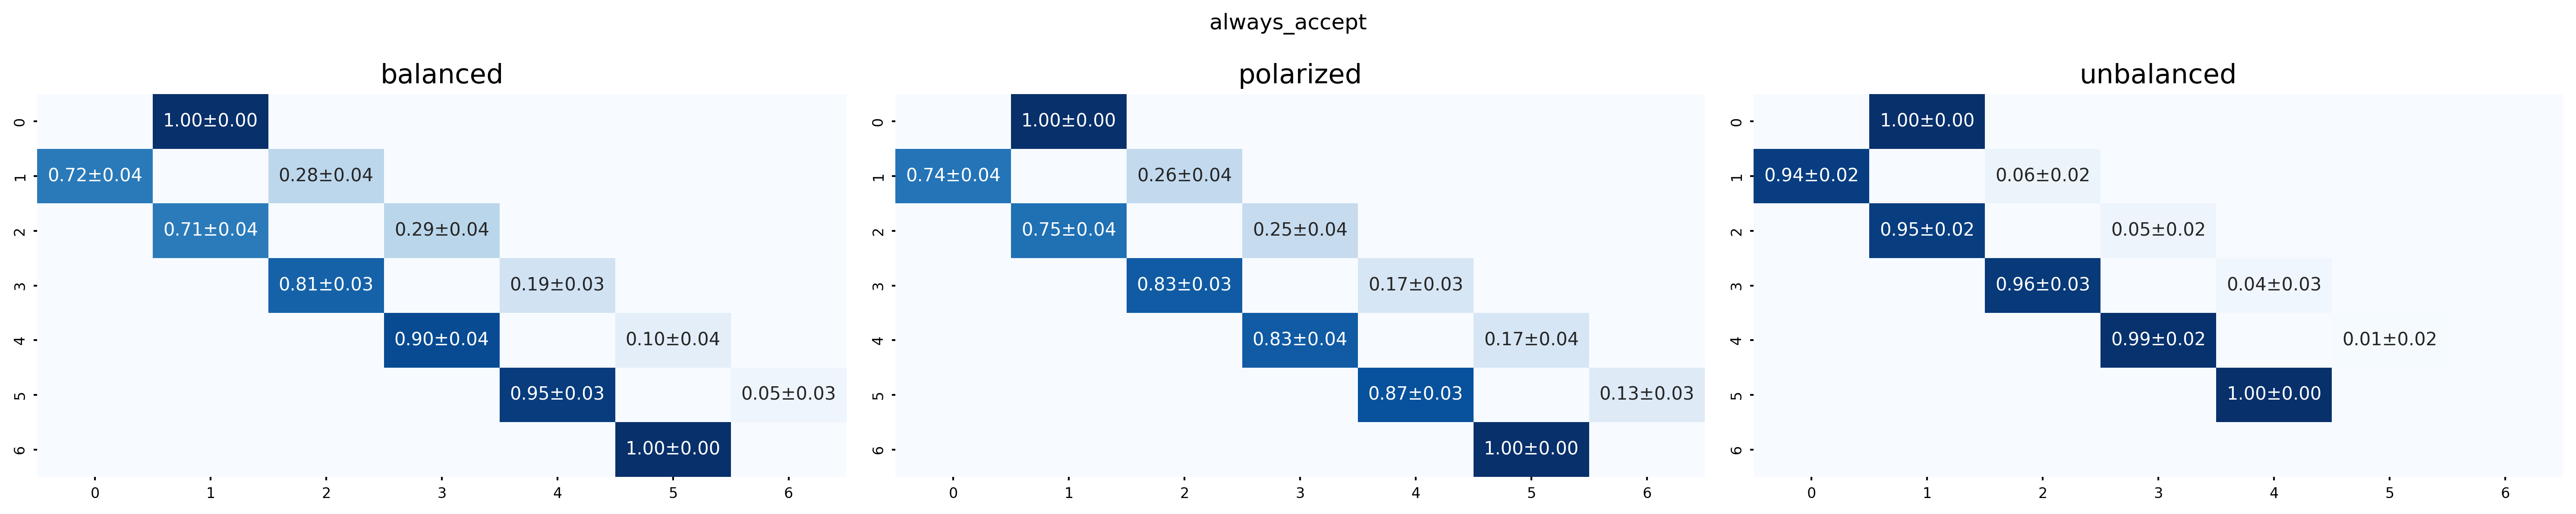

/tmp/ipykernel_842942/379097225.py:13: RuntimeWarning: invalid value encountered in divide
  transition_matrix /= transition_matrix.sum(axis=1, keepdims=True)
/tmp/ipykernel_842942/379097225.py:13: RuntimeWarning: invalid value encountered in divide
  transition_matrix /= transition_matrix.sum(axis=1, keepdims=True)
/tmp/ipykernel_842942/379097225.py:13: RuntimeWarning: invalid value encountered in divide
  transition_matrix /= transition_matrix.sum(axis=1, keepdims=True)


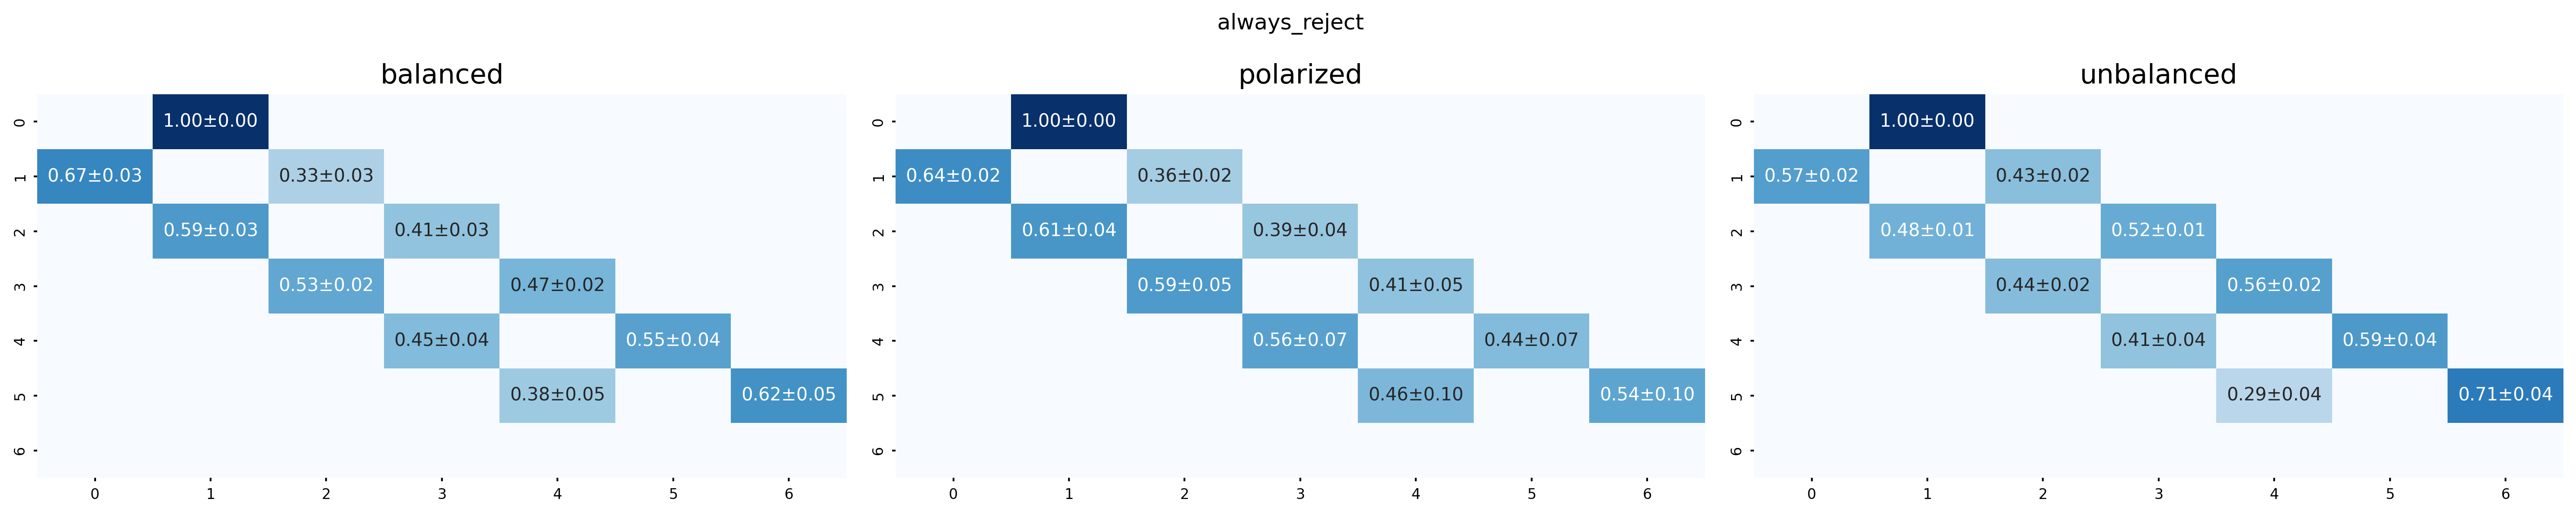

/tmp/ipykernel_842942/379097225.py:13: RuntimeWarning: invalid value encountered in divide
  transition_matrix /= transition_matrix.sum(axis=1, keepdims=True)


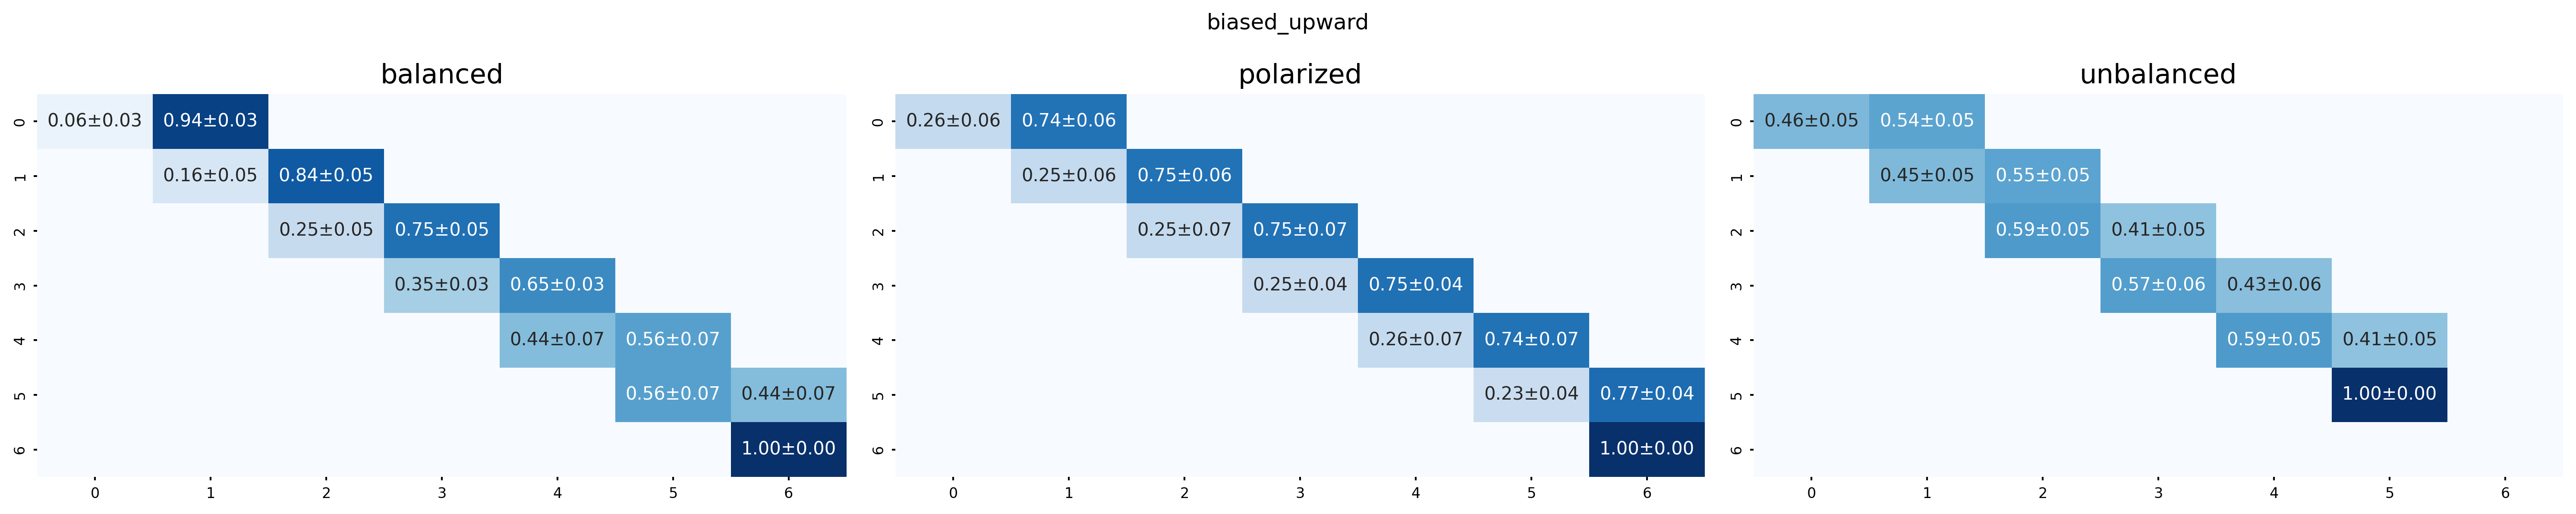

In [ ]:

for _, rule in enumerate(rules):   #remember that rules is only random for now
    
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 4))

    for col, initial in enumerate(initials):
        
        ax = axes[col]
        
        matrices = []
        for run in range(nruns):
            with open(f"results/{initial}/transition_matrix_{rule}_{run}.npy", 'rb') as f:
                transition_matrix = np.load(f)
                transition_matrix /= transition_matrix.sum(axis=1, keepdims=True)
                transition_matrix = np.nan_to_num(transition_matrix)
                matrices.append(transition_matrix)
        
        matrices = np.stack(matrices)  
        avg_transition_matrix = np.mean(matrices, axis=0)
        std_transition_matrix = np.std(matrices, axis=0)
                
        labels = np.array([[f"{mean:.2f}±{std:.2f}" if mean > 0 else "" for mean, std in zip(row_mean, row_std)]
                for row_mean, row_std in zip(avg_transition_matrix, std_transition_matrix)])
            
        hm = sns.heatmap(avg_transition_matrix, 
                         annot=labels, 
                         fmt='', 
                         cmap='Blues', 
                         cbar=False, 
                         ax=ax, 
                         annot_kws={'size': 10}, 
                         vmin=0, 
                         vmax=1)
            
        ax.set_title(f"{initial}", fontsize=15)
    
    plt.suptitle(rule)
    plt.tight_layout()  # Leave space for colorbar
    plt.show()
    plt.close()

# Computing transitions *distributions*

In [ ]:
# Loop through and plot each heatmap in the correct position
for _, initial in enumerate(initials):  # Each scenario takes 2 columns
    for _, statement in enumerate(statements):  # 'same' and 'different'
        for _, model in enumerate(models):  # llama3 (row 0), mistral (row 1)
            matrices = []
            for run in range(nruns):
                with open(f"results/{initial}/transition_matrix_{statement}_{model}_{run}.npy", 'rb') as f:
                    transition_matrix = np.load(f)
                    transition_matrix /= transition_matrix.sum(axis=1, keepdims=True)
                    transition_matrix = np.nan_to_num(transition_matrix)
                    matrices.append(transition_matrix)
            transitions_distributions = {}
            for i in opinion_space:
                for j in opinion_space:
                    key = f"{i}_{j}"
                    # Collect the transition probabilities for i->j across all runs
                    values = [matrix[i, j] for matrix in matrices]
                    transitions_distributions[key] = values
            filename_model = f'./results/{initial}/transitions_distributions_theseus_{statement}_{model}.json'
            with open(filename_model, 'w') as f:
                json.dump(transitions_distributions, f, indent=4)

/tmp/ipykernel_842942/3989450381.py:9: RuntimeWarning: invalid value encountered in divide
  transition_matrix /= transition_matrix.sum(axis=1, keepdims=True)


In [ ]:
for _, rule in enumerate(rules):   
    for _, initial in enumerate(initials):        
        matrices = []
        for run in range(nruns):
            with open(f"results/{initial}/transition_matrix_{rule}_{run}.npy", 'rb') as f:
                transition_matrix = np.load(f)
                transition_matrix /= transition_matrix.sum(axis=1, keepdims=True)
                transition_matrix = np.nan_to_num(transition_matrix)
                matrices.append(transition_matrix)
        transitions_distributions = {}
        for i in opinion_space:
            for j in opinion_space:
                key = f"{i}_{j}"
                # Collect the transition probabilities for i->j across all runs
                values = [matrix[i, j] for matrix in matrices]
                transitions_distributions[key] = values
        filename_null = f'./results/{initial}/transitions_distribution_{rule}.json'
        with open(filename_null, 'w') as f:
            json.dump(transitions_distributions, f, indent=4)

/tmp/ipykernel_842942/1749880372.py:7: RuntimeWarning: invalid value encountered in divide
  transition_matrix /= transition_matrix.sum(axis=1, keepdims=True)


# Test statistici

Hypothesis testing is a fundamental statistical method for inferring population parameters based on sample data. It provides a structured approach for evaluating claims or assumptions about a population using empirical evidence.

At the core of hypothesis testing are two complementary statements:

- The **null hypothesis (H₀)** is a statement of no effect, difference, or relationship. It represents the status quo or the current understanding.
- The **alternative hypothesis (H₁)** is a statement that contradicts the null hypothesis. It represents the claim or the new understanding that the researcher wants to prove.

Hypothesis testing involves collecting sample data, calculating test statistics, and determining the probability of observing such results if the null hypothesis is true. Based on this probability, we can decide whether to reject the null hypothesis in favor of the alternative or fail to reject it.

Depending on the data types and research questions tested, several statistical tests are available for hypothesis testing. In this tutorial, we will focus on the t-test and Z-test.


## T-test
A t-test is a statistical test used to determine whether there is a significant difference between the means of two groups or between a sample mean and a known value. It is particularly useful when dealing with small sample sizes or when the population standard deviation is unknown. 

The t-test statistic for a one sample test is calculated using the formula:

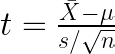

where:

- Xˉ is the sample mean
- μ is the population mean (or the mean of the comparison group)
- s is the sample standard deviation, and 
- n is the sample size.

There are three main types of t-tests. Each compares means under different conditions:

- One-Sample t-test: This test compares the mean of a single sample to a known value or population mean. It determines if the sample mean significantly deviates from a specific benchmark. For example, we can use a one-sample t-test to evaluate whether the average test score of a small class differs from the national average.
- **Independent Two-Sample t-test**: This test compares the means of two independent groups to determine if there is a statistically significant difference between them. It is commonly used in experiments where two groups undergo different treatments or conditions. For instance, we could use an independent two-sample t-test to compare test scores between students taught using two different teaching methods to see if one method is more effective.
- Paired t-test: This test compares means from the same group at different times or under different conditions. It evaluates whether there is a significant change within the same group after an intervention or over time. An example is measuring student performance before and after implementing a new teaching strategy to assess its impact.

The t-test relies on certain assumptions to provide valid results:

- ✅ Normality of the Data: The t-test assumes that the data in each group are approximately normally distributed. This is especially important when dealing with small sample sizes. If the data are not normally distributed, the t-test results may be unreliable.
- ❌ Homogeneity of Variances: For an independent two-sample t-test, the variances of the two groups being compared are assumed to be equal. This assumption ensures that the t-test correctly accounts for variability within each group. If the variances are not equal, it can affect the accuracy of the test.
- ❓ Independence of Observations: The observations within each group should be independent. This means that the value of one observation should not influence or be related to the value of another observation. Violation of this assumption can lead to incorrect conclusions.

## Mann–Whitney U test

The Mann–Whitney U test (also called the Mann–Whitney–Wilcoxon (MWW/MWU), Wilcoxon rank-sum test, or Wilcoxon–Mann–Whitney test) is a nonparametric statistical test of the null hypothesis that randomly selected values X and Y from two populations have the same distribution.

## Z-Score test
A Z-score measures exactly how many standard deviations above or below the mean a data point is.
Two sample Z-test is used when we need to compare two sample means.

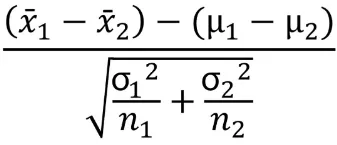

x̄1 : Mean of Sample 1; x̄2 : Mean of Sample 1

μ1 : Population mean of Sample 1; μ2 : Population mean of Sample 2

σ1 : Population standard deviation of Sample 1; σ2 : Population standard deviation of Sample 2

n1 : Size of Sample 1; n2: Size of Sample 2


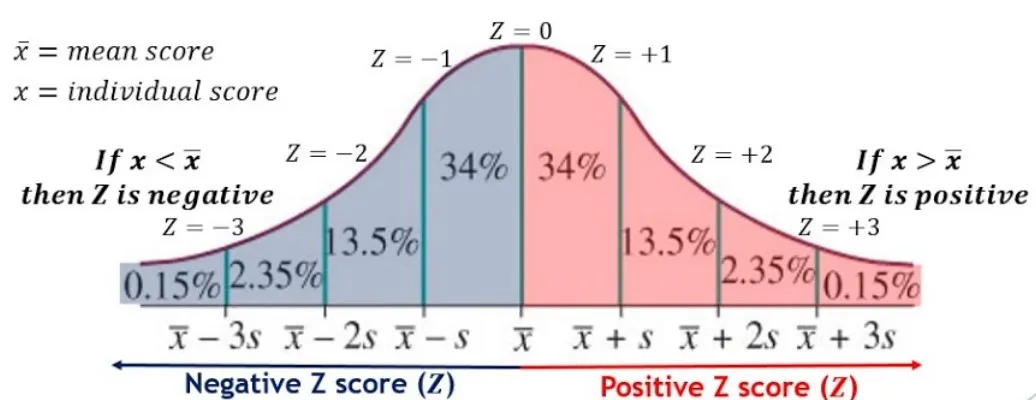

Types of Z-tests
There are three main types of Z-tests:

- One-Sample Z-test: This test compares the mean of a single sample to a known population mean. It is used when you want to assess whether the sample mean significantly deviates from the population mean, assuming the population variance is known. For example, a one-sample z-test might be used to determine if the average height of a group of more than 30 people differs from the known national average height.
- **Two-Sample Z-test**: This test compares the means of two independent samples to determine if there is a significant difference between them. It is used when both samples are large and the population variances are known. An example of this would be comparing the average test scores of students from two different schools to see if there is a significant difference in performance between the two schools.
- Proportion Z-test: This test compares the proportion of a certain characteristic in a sample to a known population proportion or between two sample proportions. It is used to evaluate whether the observed proportion in the sample significantly differs from what is expected based on the population proportion. For instance, a proportion Z-test might be used to compare the proportion of voters favoring a particular candidate in a sample to the proportion observed in previous elections.

There are additional variations of the test, such as the paired Z-test, the Z-test for regression coefficients, and the Z-test for differences in means. 

Assumptions of the Z-test
The Z-test relies on certain assumptions to provide valid results:

1. Known Population Variance: The Z-test assumes that the population variance is known. This is a key distinction from the t-test, where the population variance is typically unknown. The known variance allows for using the z-distribution to assess the significance of the test statistic.
2. Large Sample Size: The Z-test assumes a large sample size, typically greater than 30. With larger samples, the sampling distribution of the sample mean approaches a normal distribution, even if the original data are not normally distributed, according to the Central Limit Theorem.
3. Normal Distribution of the Population: The data are assumed to be drawn from a normally distributed population. This assumption is less critical for large samples but still important when the sample size is moderate.

# Pipeline

In [8]:
import numpy as np
import scipy.stats as stats
import pandas as pd
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
c = (1 / 2.54) / 10 
width = 170*c*1.3
height = 80*c*1.5

In [12]:
def statistical_tests_transitions(rule, alpha = 0.05):
    # Loop through and plot each heatmap in the correct position
    for _, initial in enumerate(initials):  # Each scenario takes 2 columns
        
        fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(width, height), dpi=300)
        
        heatmaps = []
        
        for col, statement in enumerate(statements):  # 'same' and 'different'
            
            for row, model in enumerate(models):  # llama3 (row 0), mistral (row 1)
                
                filename_model = f'./results/{initial}/transitions_distributions_theseus_{statement}_{model}.json'
                with open(filename_model, 'r') as f:
                    transitions_model = json.load(f)
                
                filename_null = f'./results/{initial}/transitions_distribution_{rule}.json'
                with open(filename_null, 'r') as f:
                    transitions_null = json.load(f)
            
                E = np.empty((7, 7), dtype=object)
                N = np.empty((7, 7), dtype=object)
                
                # Initialize all with empty lists
                for i in range(7):
                    for j in range(7):
                        E[i, j] = []
                        N[i, j] = []

                # Fill with data
                for key in transitions_model:
                    i, j = map(int, key.split('_'))
                    E[i, j] = transitions_model[key]
                    N[i, j] = transitions_null[key]
                                
                p_values = np.zeros((len(opinion_space), len(opinion_space)))
                tstats = np.zeros((len(opinion_space), len(opinion_space)))

                for i in range(len(opinion_space)):
                    for j in range(len(opinion_space)):
                        
                        a = E[i, j]
                        b = N[i, j]

                        stat, p = stats.ttest_ind(a, b, equal_var=False)

                        
                        p_values[i, j] = p
                        tstats[i, j] = stat
                
                # Flatten p-values for correction
                p_values_flat = p_values.flatten()
                rejected = p_values < alpha

                # Reshape back to matrix form
                pvals_corrected_matrix = p_values_flat.reshape(len(opinion_space), len(opinion_space))
                significant_mask = rejected.reshape(len(opinion_space), len(opinion_space))

                avg_transition_matrix = np.array([[np.mean(E[i, j]) for j in range(len(opinion_space))] for i in range(len(opinion_space))])
                std_transition_matrix = np.array([[np.std(E[i, j]) for j in range(len(opinion_space))] for i in range(len(opinion_space))])

                # Create masked labels: show value only where significant
                labels = np.array([
                    [
                        f"{mean:.2%}\n±{std:.2%}" if significant_mask[i, j] else ''
                        for j, (mean, std) in enumerate(zip(row_mean, row_std))
                    ]
                    for i, (row_mean, row_std) in enumerate(zip(avg_transition_matrix, std_transition_matrix))
                ])

                # Mask: True where NOT significant (we want to white those out)
                mask = ~significant_mask

                # Plot heatmap without masking
                hm = sns.heatmap(
                    avg_transition_matrix,
                    annot=labels,
                    fmt='',
                    cmap='Blues',
                    cbar=False,
                    ax=ax[row, col],
                    vmin=0, vmax=1,
                    annot_kws={'size': 6},
                    #linewidths=0.5,  # Optional for visible grid
                    #linecolor='lightgray'
                )

                # Add rectangles to significant cells
                for i in range(len(opinion_space)):
                    for j in range(len(opinion_space)):
                        if significant_mask[i, j]:
                            rect = plt.Rectangle(
                                (j, i), 1, 1, fill=False, edgecolor='black', linewidth=0.5
                            )
                            ax[row, col].add_patch(rect)
                            
                heatmaps.append(hm)
                ax[row, col].set_title(f'{model.capitalize()} | {statement.capitalize()}', size=8)
                        
                plot_label = {
                "llama3_same": "(c)",
                "llama3_different": "(d)",
                "mistral_same": "(a)",
                "mistral_different": "(b)"
                }
                
                ax[row, col].text(6.75, 0.5, f"{plot_label[f'{model}_{statement}']}", fontweight='bold', fontsize=6)

        ax[0, 0].set_ylabel(r'$x_D(t)$', fontsize=7)
        ax[1, 0].set_ylabel(r'$x_D(t)$', fontsize=7)
        ax[1, 0].set_xlabel(r'$x_D(t+1)$', fontsize=7)
        ax[1, 1].set_xlabel(r'$x_D(t+1)$', fontsize=7)
        
        # Shared colorbar on the right
        cbar_ax = fig.add_axes([0.25, 0.93, 0.5, 0.02])  # [left, bottom, width, height]
        fig.colorbar(heatmaps[0].collections[0], cax=cbar_ax, orientation='horizontal')
        
        #plt.suptitle(initial)
        plt.tight_layout(rect=[0, 0, 1, 0.9])  # leave space for top colorbar
        
        plt.savefig(f'figures/{initial}/average_transitions_statistical_significance_{initial}.pdf', bbox_inches='tight')

/tmp/ipykernel_876608/1435220579.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.9])  # leave space for top colorbar
/tmp/ipykernel_876608/1435220579.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.9])  # leave space for top colorbar
/tmp/ipykernel_876608/1435220579.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.9])  # leave space for top colorbar


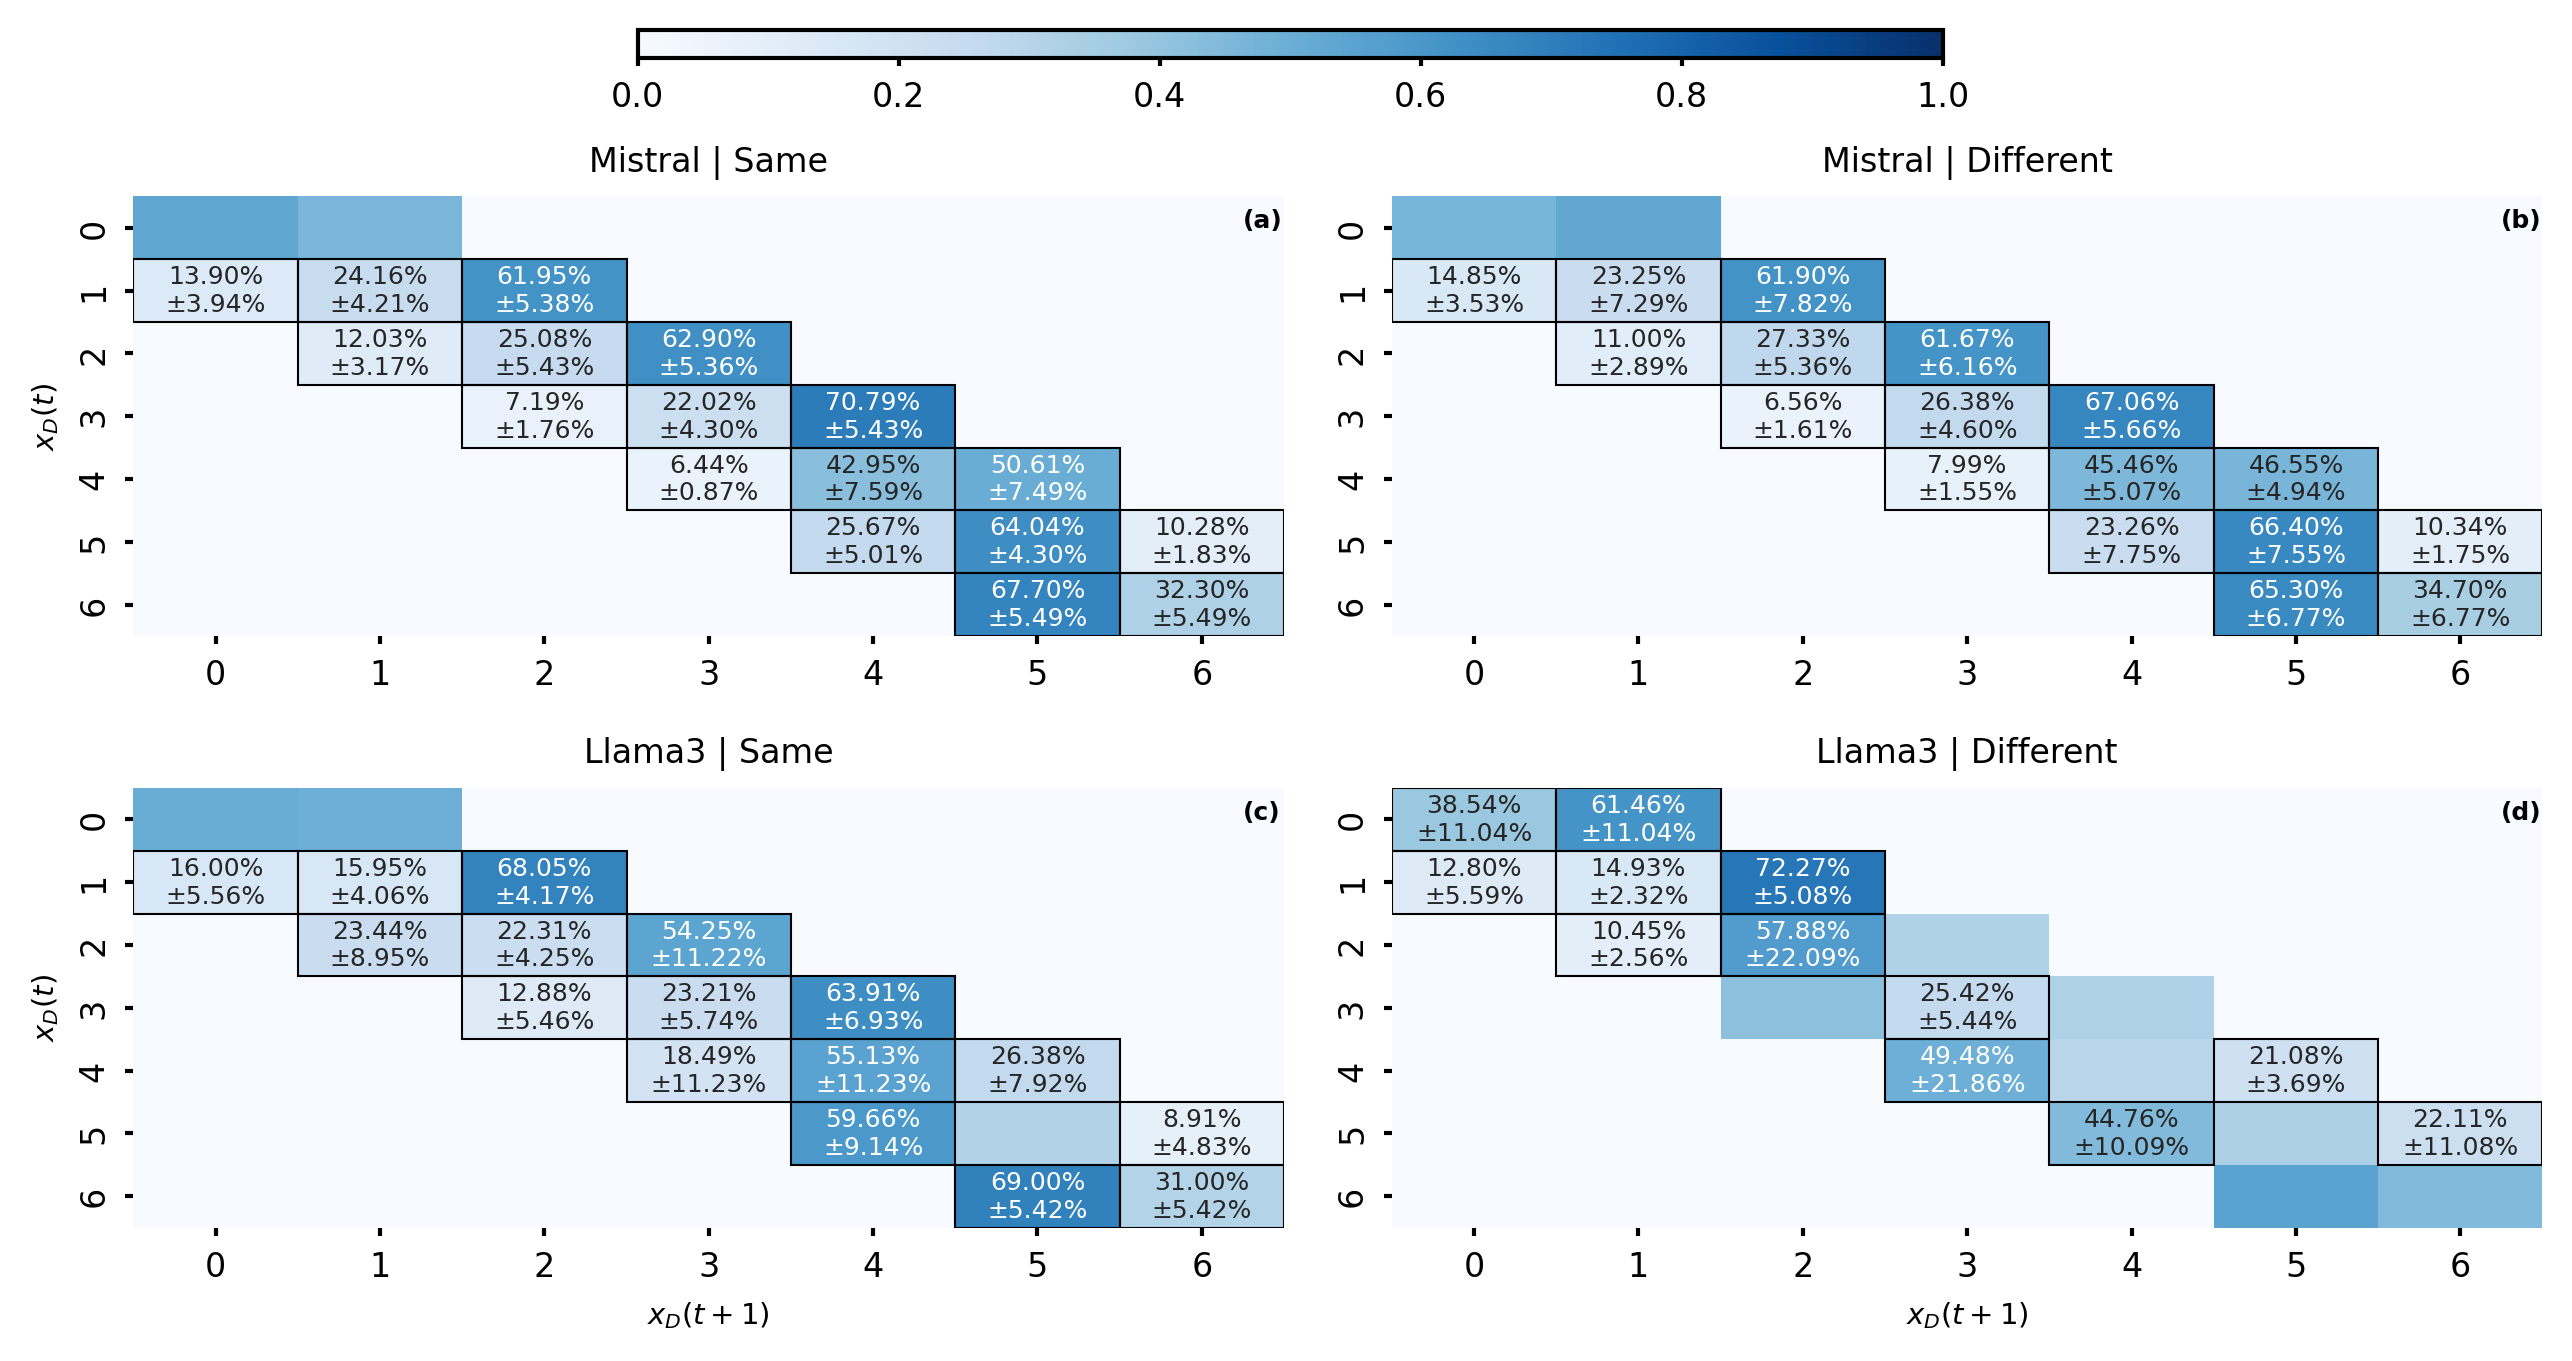

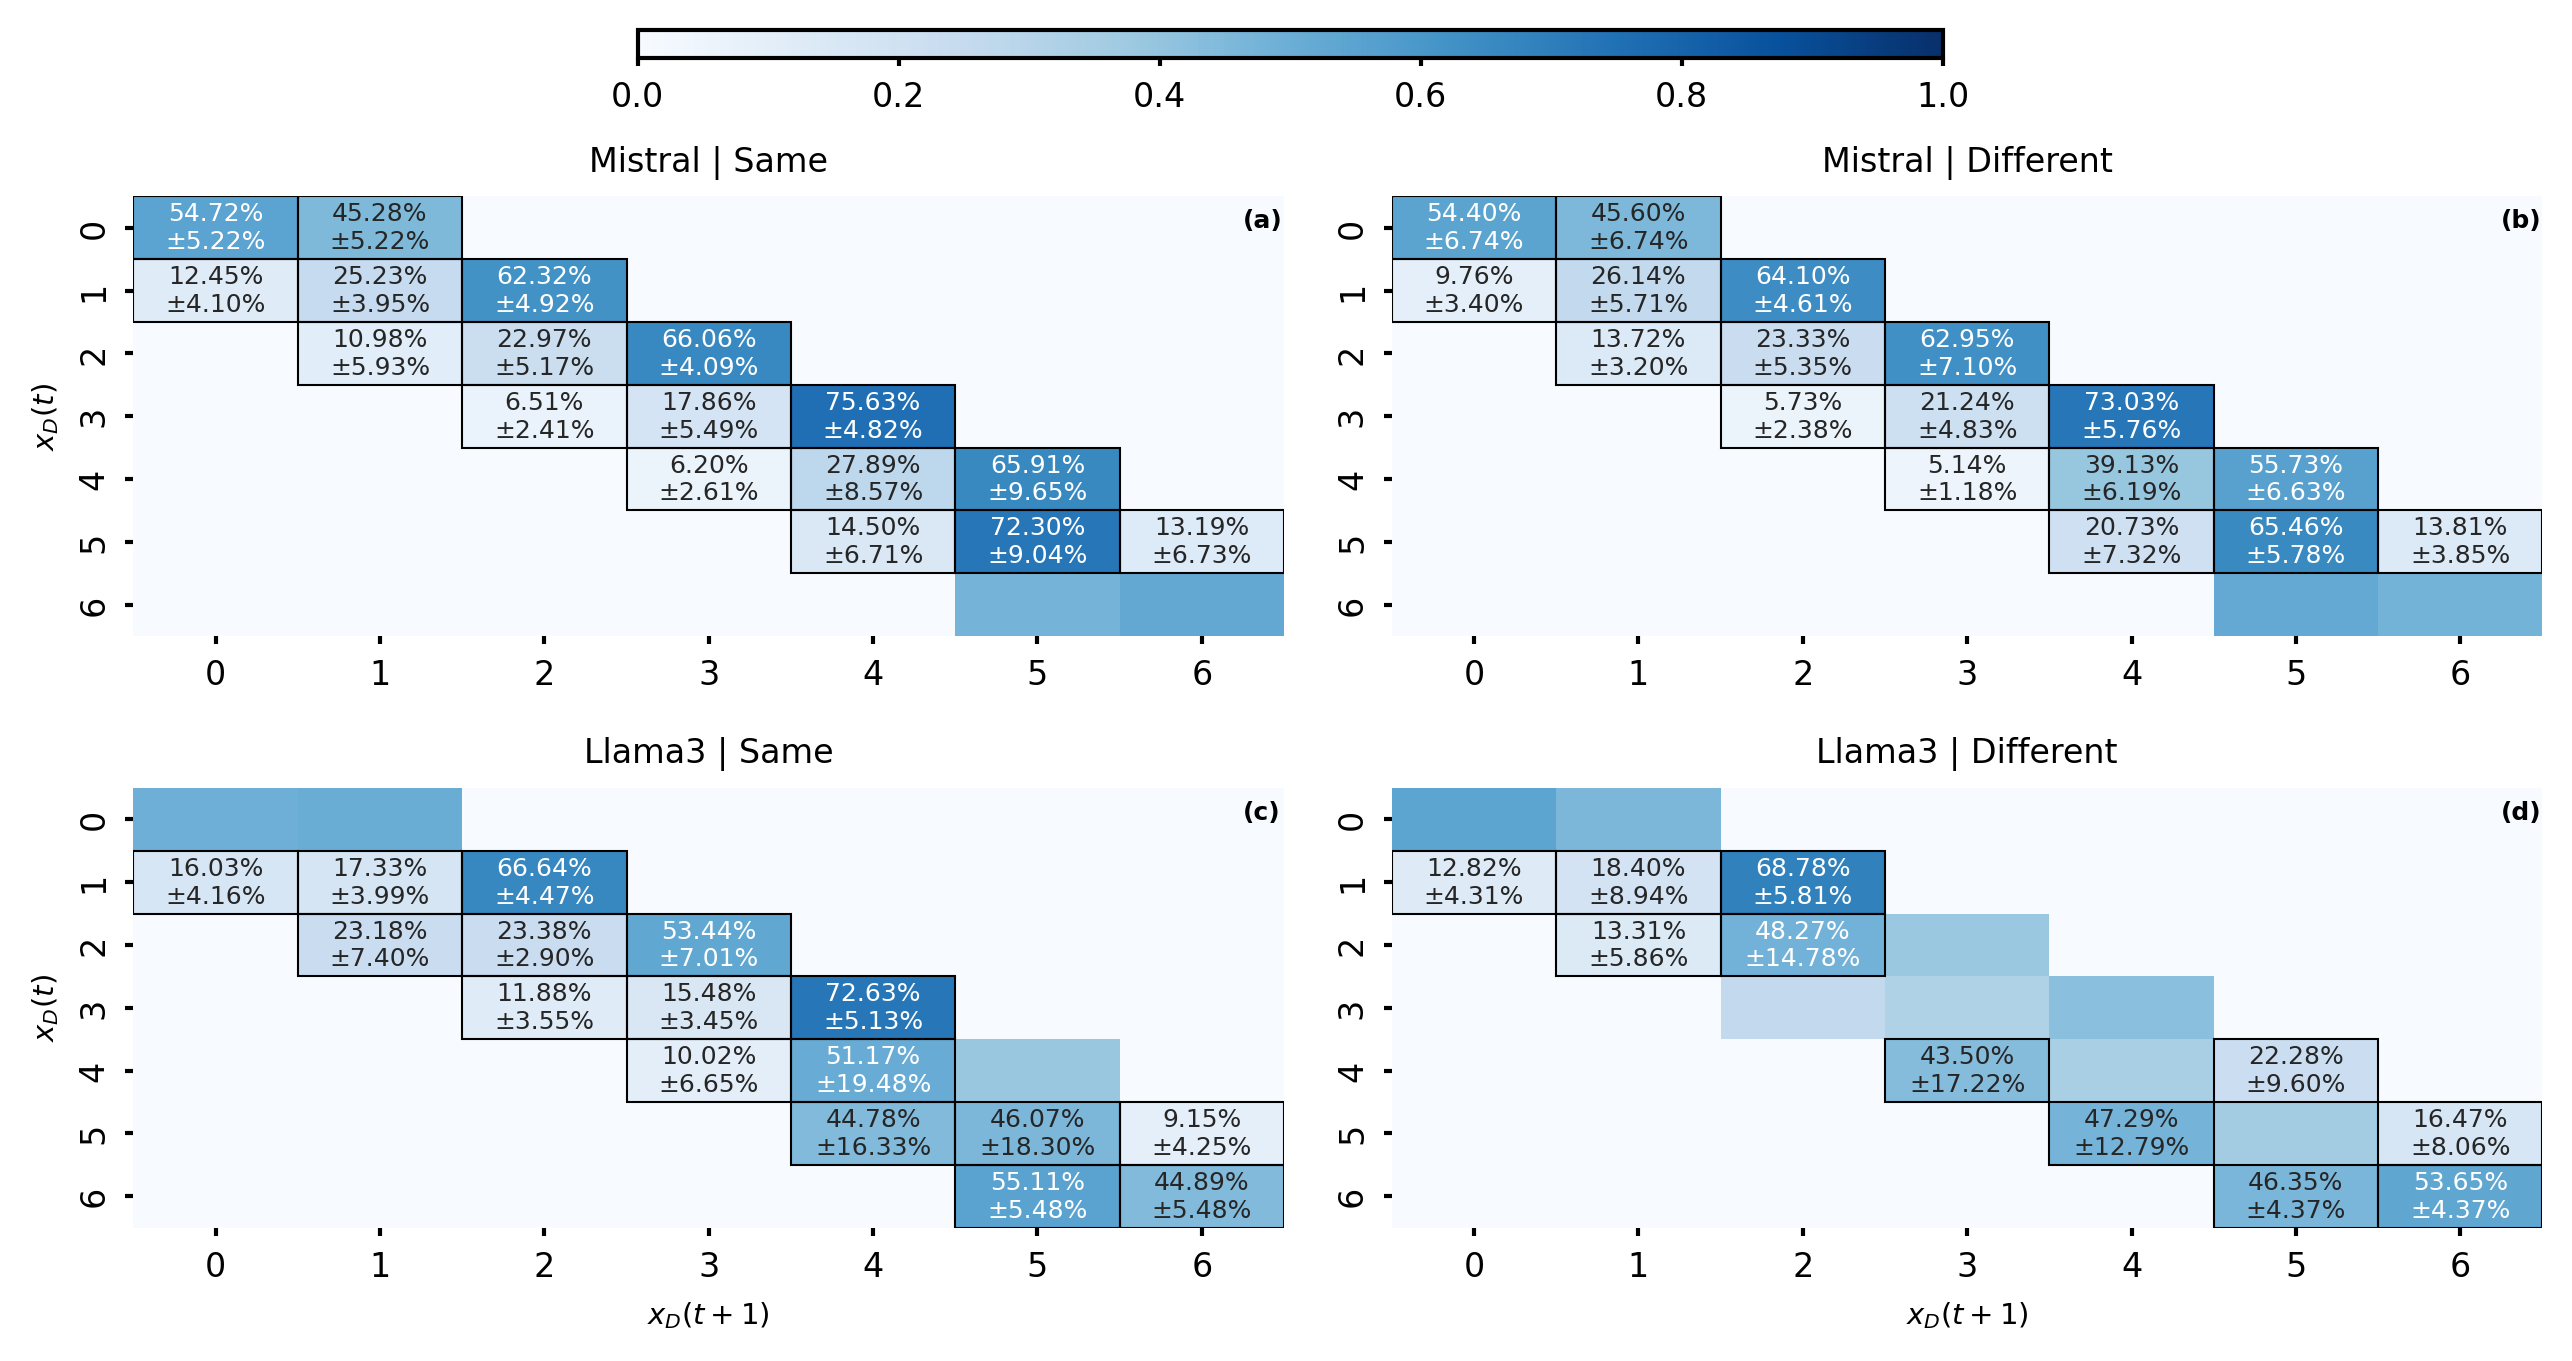

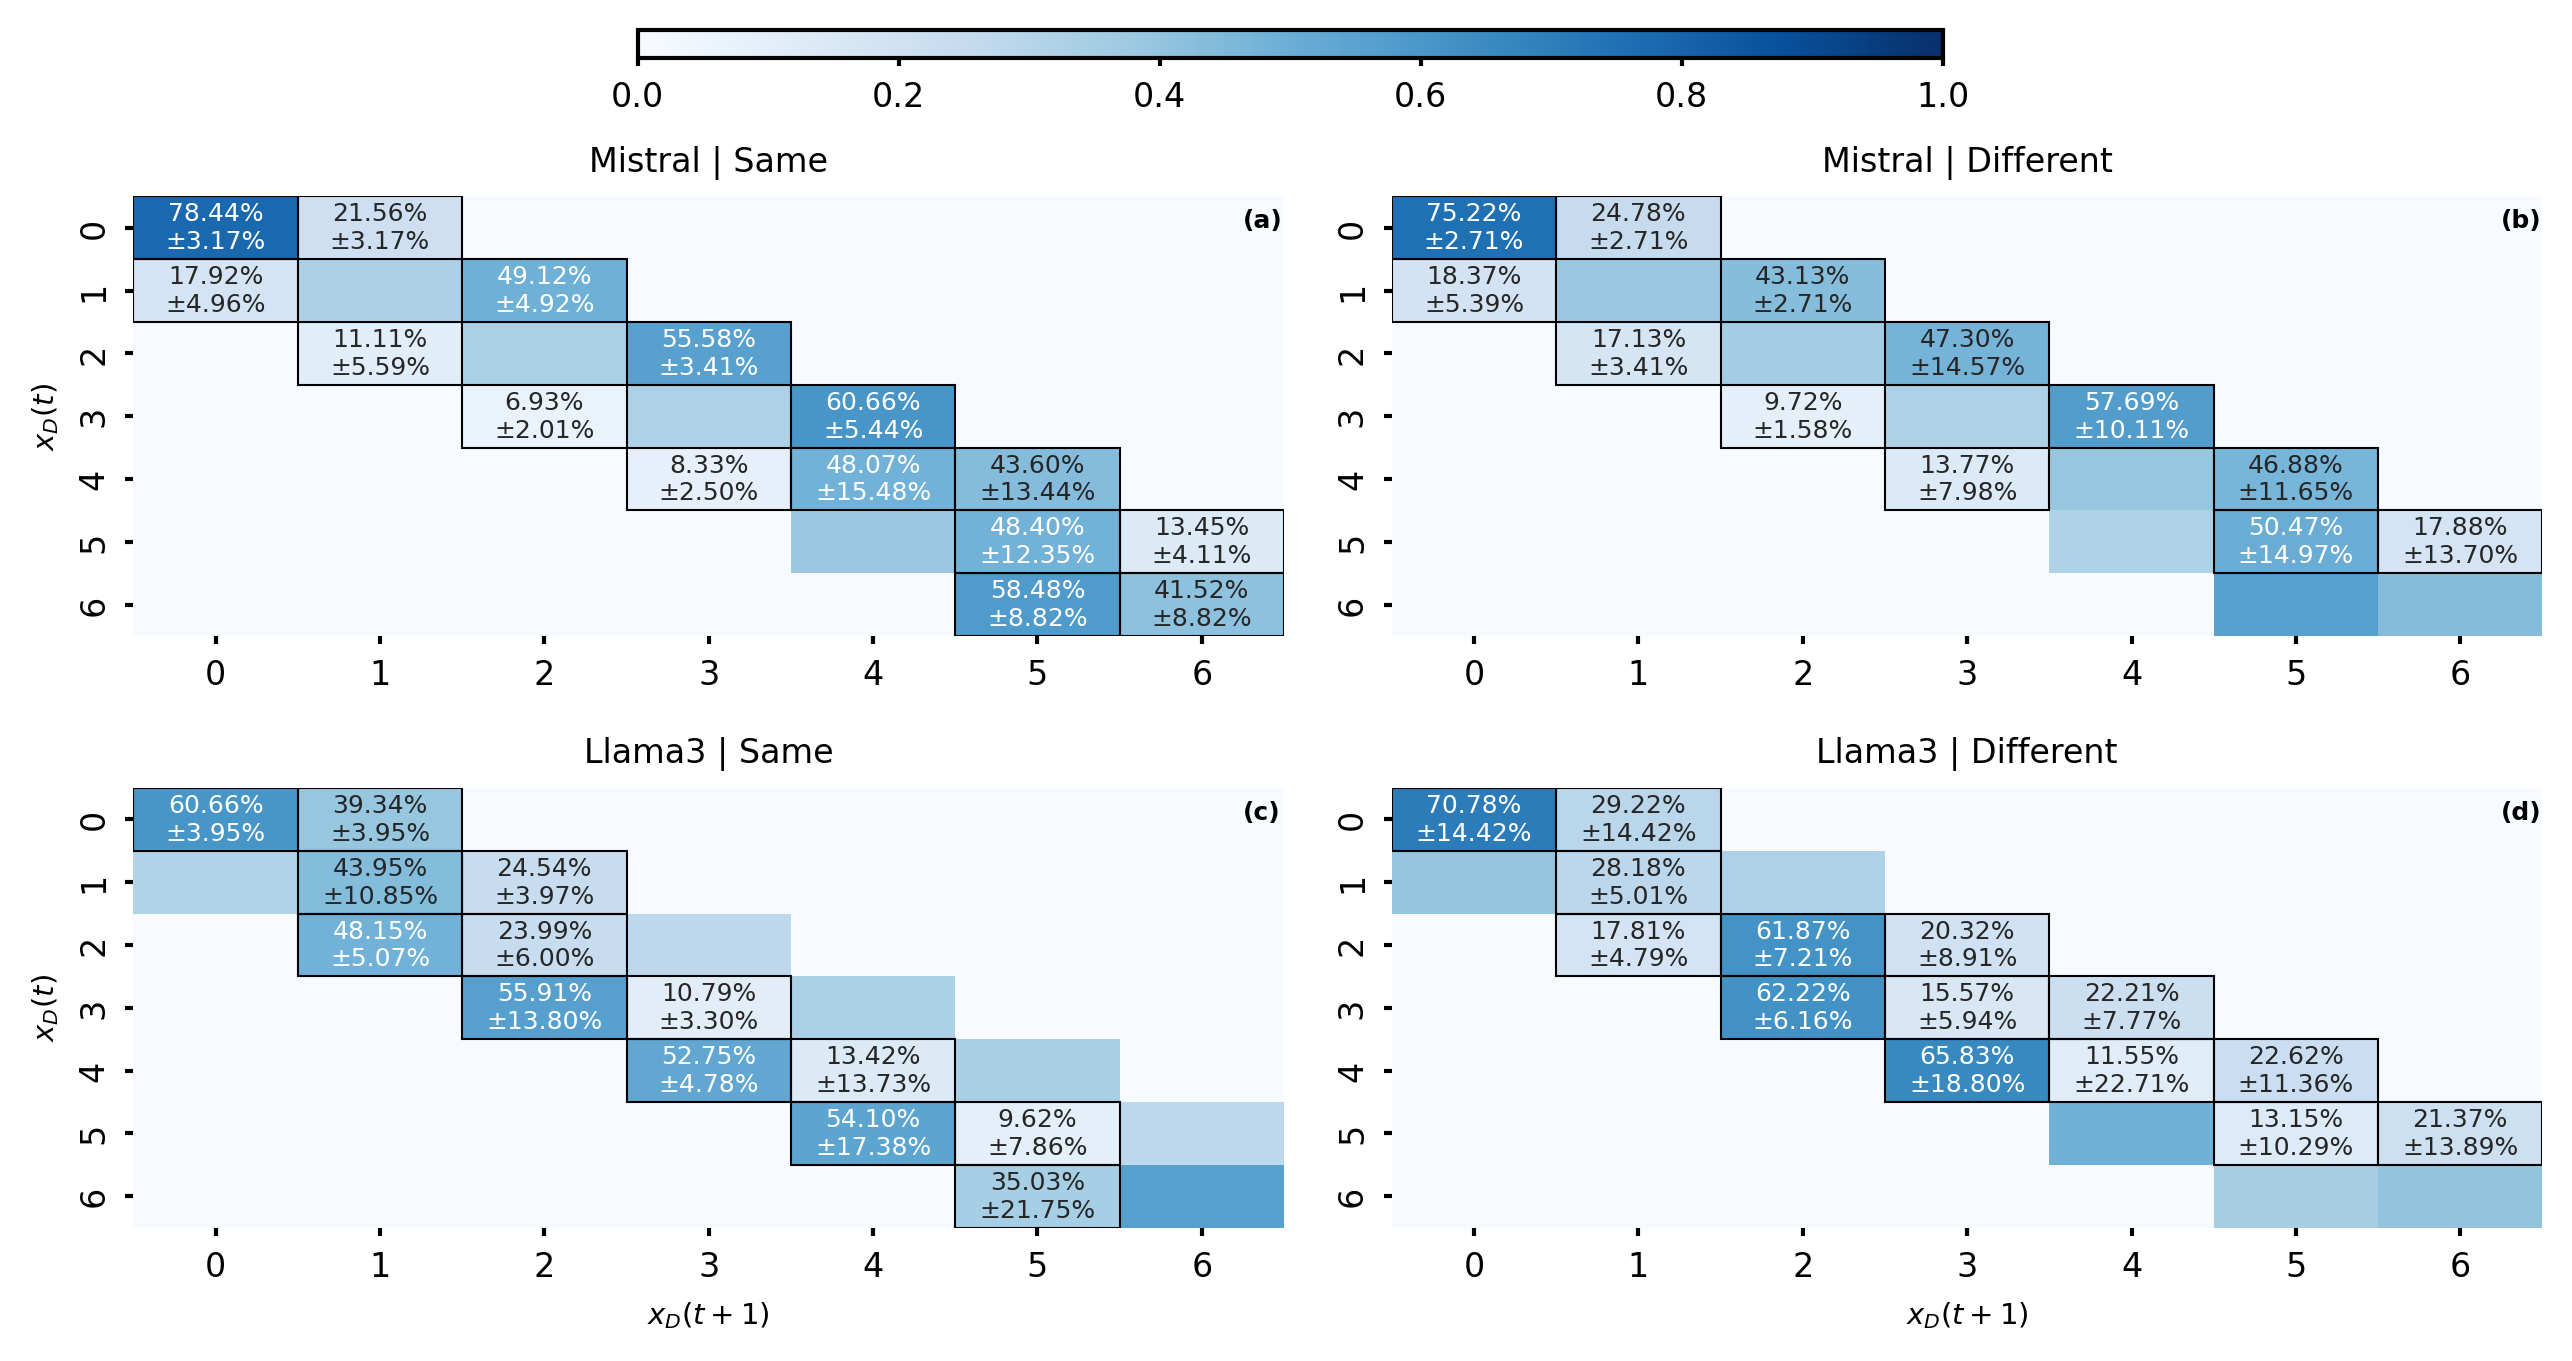

In [13]:
statistical_tests_transitions("random", alpha = 0.05)